<a href="https://colab.research.google.com/github/bhavananamburi/oasis-infobyte-internship-/blob/main/Bhavana_task3__Cleaning_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Loading the Data**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving AB_NYC_2019.csv to AB_NYC_2019.csv


In [ ]:
df = pd.read_csv("AB_NYC_2019.csv")

In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,10/19/2018,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,5/21/2019,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,7/5/2019,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,11/19/2018,0.10,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


 **Checking Missing Values**

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


**Missing Values by Column**

/tmp/ipykernel_1174/3175188658.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




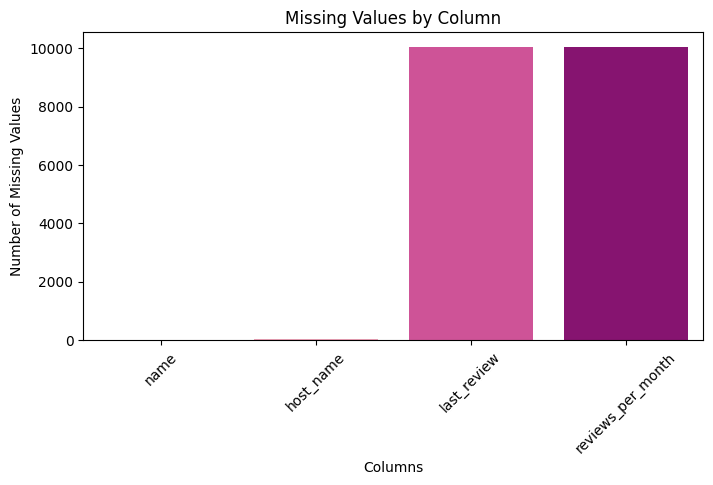

In [ ]:
df.isnull().sum()

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8,4))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values,
    palette='RdPu'
)

plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)

plt.show()


# **Fixing Missing Values**

In [ ]:

df['name'] = df['name'].fillna('Unknown')

df['host_name'] = df['host_name'].fillna('Unknown')

df['reviews_per_month'] = df['reviews_per_month'].fillna(
    df['reviews_per_month'].median()
)

df['last_review'] = df['last_review'].fillna('No Review')

In [ ]:
df.isnull().sum()


,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


 **Checking Duplicate Records**

In [ ]:
df.duplicated().sum()

np.int64(0)

**Data quality information** (Dashboard)

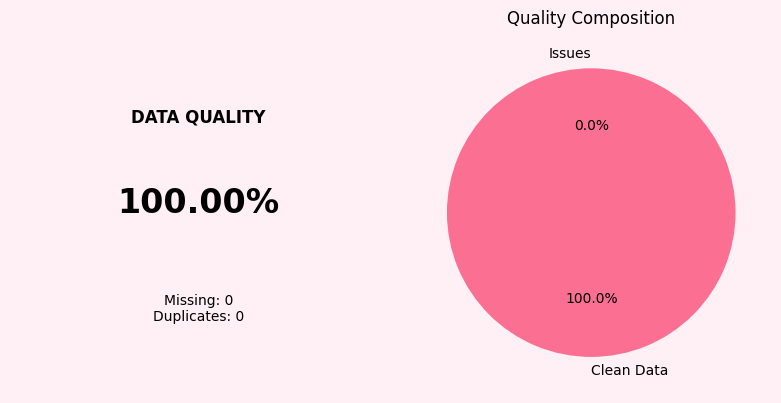

In [ ]:

total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

quality_score = (
    (1 - missing_cells/total_cells) *
    (1 - duplicate_rows/len(df))
) * 100

fig, ax = plt.subplots(1, 2, figsize=(8,4))

fig.patch.set_facecolor('#FFF0F5')

ax[0].set_facecolor('#FFE4E9')
ax[0].axis('off')

ax[0].text(
    0.5, 0.75,
    "DATA QUALITY",
    ha='center',
    fontsize=12,
    fontweight='bold'
)

ax[0].text(
    0.5, 0.5,
    f"{quality_score:.2f}%",
    ha='center',
    fontsize=24,
    fontweight='bold'
)

ax[0].text(
    0.5, 0.2,
    f"Missing: {missing_cells}\nDuplicates: {duplicate_rows}",
    ha='center',
    fontsize=10
)

ax[1].set_facecolor('#FFF0F5')

ax[1].pie(
    [quality_score, 100-quality_score],
    labels=['Clean Data', 'Issues'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#fb6f92', '#be1558']
)

ax[1].set_title("Quality Composition")

plt.tight_layout()
plt.show()

In [ ]:
df['neighbourhood_group'] = df['neighbourhood_group'].str.title()

df['room_type'] = df['room_type'].str.title()

df['host_name'] = df['host_name'].str.strip()

**Changing column names**

In [ ]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")

# **Outliers**

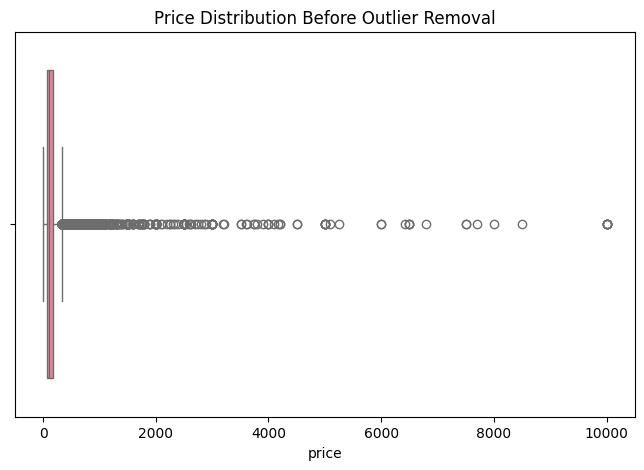

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['price'],
    color='#fb6f92'
)

plt.title("Price Distribution Before Outlier Removal")

plt.show()

**Removing Outliers**

In [ ]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_clean = df.copy()
df_clean = df_clean[(df_clean['price'] >= lower) & (df_clean['price'] <= upper)]

In [ ]:
print("Original Dataset Shape:", df.shape)

print("Cleaned Dataset Shape:", df_clean.shape)

print("Outliers Removed:", len(df)-len(df_clean))

Original Dataset Shape: (48895, 16)
Cleaned Dataset Shape: (45923, 16)
Outliers Removed: 2972


**Boxplot After Removing Outliers**

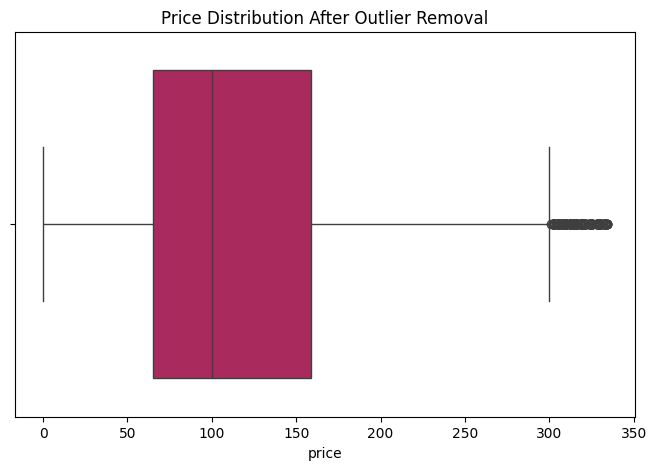

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_clean['price'],
    color='#be1558'
)

plt.title("Price Distribution After Outlier Removal")

plt.show()

**Final Data Quality Check**

In [ ]:
df_clean.isnull().sum()
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean.to_csv("cleaned_airbnb_nyc.csv", index=False)

**Distribution of Listings by Neighbourhood Group and Room Type**(Treemap)

In [ ]:
import plotly.express as px

fig = px.treemap(
    df,
    path=['neighbourhood_group', 'room_type'],
    title='Distribution of Listings by Neighbourhood Group and Room Type',
    color='neighbourhood_group',
    color_discrete_sequence=[
        '#ffcce7', '#be1558','#ffb3d9', '#ff8fab','#fb6f92',
    ]
)

fig.update_layout(
    title_x=0.5,
    paper_bgcolor='#fff5fa',
    plot_bgcolor='#fff5fa',
    margin=dict(t=60, l=25, r=25, b=25)
)

fig.show()

**Correlation Matrix Heatmap**

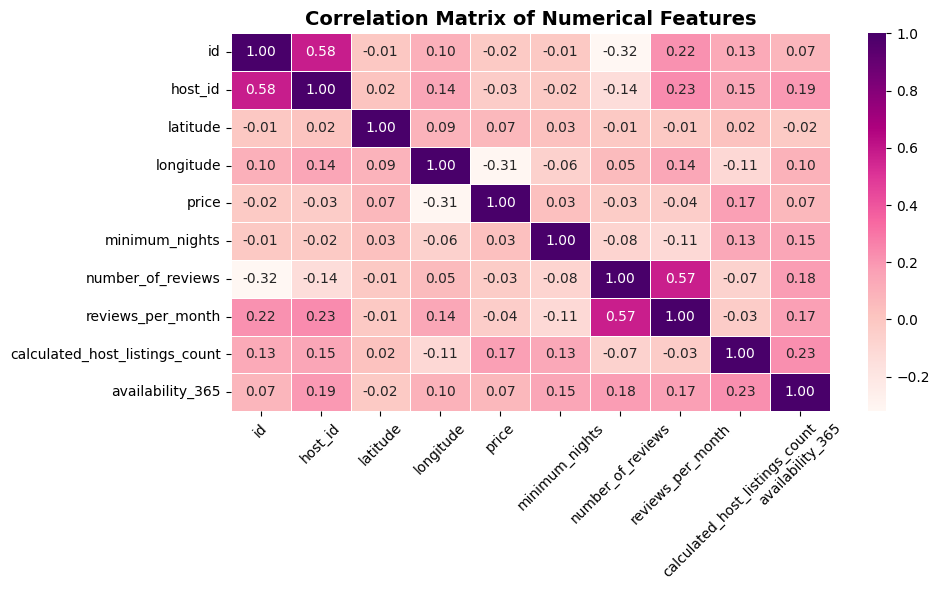

In [ ]:
plt.figure(figsize=(10,6))

corr_matrix = df_clean.select_dtypes(
    include=['int64', 'float64']
).corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdPu',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=14,
    fontweight='bold'
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Distribution of Airbnb Listing Prices**

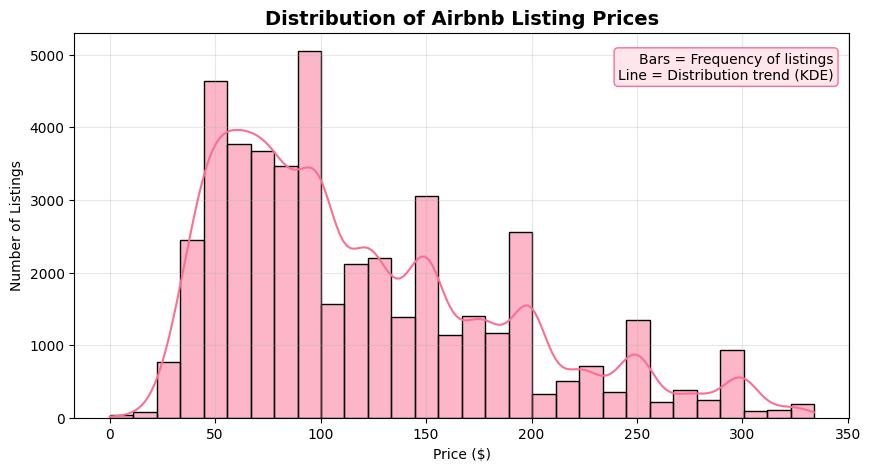

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_clean['price'],
    bins=30,
    kde=True,
    color='#fb6f92'
)

plt.title(
    "Distribution of Airbnb Listing Prices",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.text(
    0.98, 0.95,
    "Bars = Frequency of listings\nLine = Distribution trend (KDE)",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round',
        facecolor='#ffe5ec',
        edgecolor='#fb6f92'
    )
)

plt.grid(alpha=0.3)

plt.show()

**Average Price by Neighbourhood Group**

/tmp/ipykernel_1174/2098339821.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




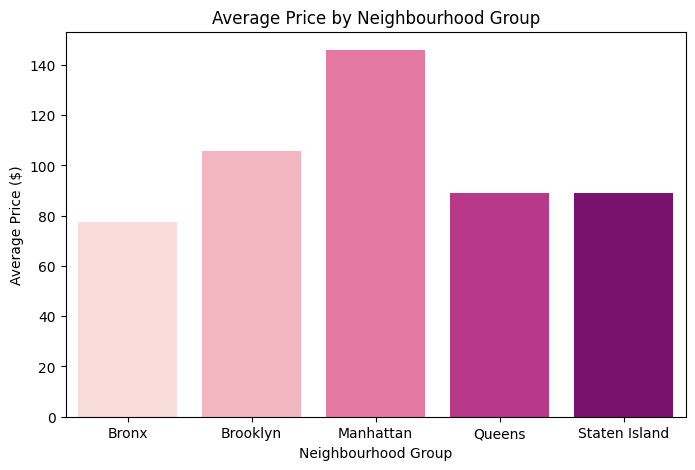

In [ ]:
avg_price = df_clean.groupby('neighbourhood_group')['price'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette='RdPu'
)

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price ($)")

plt.show()